In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')

# fill missing values
df['age'] = df['age'].fillna(df['age'].median())
for col in ['embarked', 'deck', 'embark_town']:
    df[col] = df[col].fillna(df[col].mode()[0])

# clip outliers (numeric columns)
for col in df.select_dtypes(include='number'):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# remove duplicates and drop columns
df = df.drop_duplicates().drop(columns=['alive','embark_town','who'])

print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0    1.0      0   7.2500        S  Third   
1         1       1  female  38.0    1.0      0  65.6344        C  First   
2         1       3  female  26.0    0.0      0   7.9250        S  Third   
3         1       1  female  35.0    1.0      0  53.1000        S  First   
4         0       3    male  35.0    0.0      0   8.0500        S  Third   

   adult_male deck  alone  
0        True    C  False  
1       False    C  False  
2       False    C   True  
3       False    C  False  
4        True    C   True  


Shape: (150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Correlation Matrix:
                    sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)              1.000            -0.118              0.872   
sepal width (cm)              -0.118             1.000             -0.428   
petal length (cm)              0.872            -0.428              1.000   
petal width (cm)               0.818            -0.366              0.963   

                   petal width (cm)  
sepal length (cm)             0.818  
sepal width (cm)             -0.366  
petal 

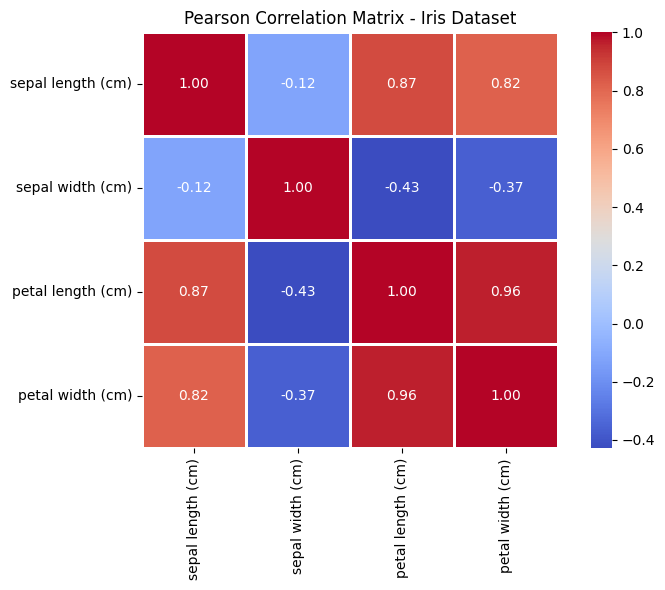

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# load dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

# show basic info
print("Shape:", df.shape)
print(df.head())

# compute correlation using built-in function
corr = df.corr()

# display correlation matrix
print("\nCorrelation Matrix:\n", corr.round(3))

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=1, square=True)

plt.title("Pearson Correlation Matrix - Iris Dataset")
plt.tight_layout()
plt.show()

Coefficient: 0.4193384939381274
Intercept: 0.44459729169078677
MAE: 0.629908653009376
RMSE: 0.8420901241414454
R2 Score: 0.45885918903846656


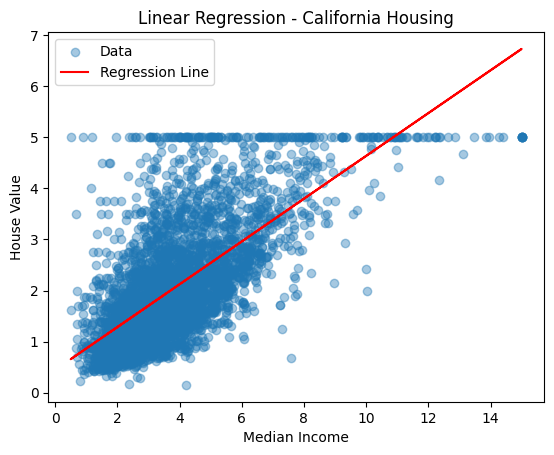

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# load dataset
data = fetch_california_housing()
X = data.data[:, [0]]   # Median Income
y = data.target

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
model = LinearRegression()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluation
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# visualization
plt.scatter(X_test, y_test, alpha=0.4, label="Data")
plt.plot(X_test, y_pred, color='red', label="Regression Line")

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Linear Regression - California Housing")
plt.legend()
plt.show()

Accuracy: 0.9


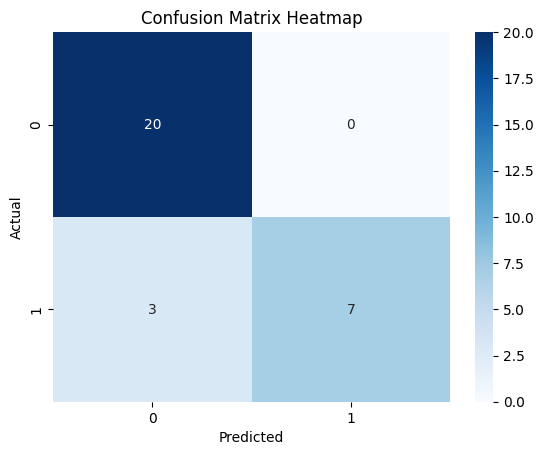

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# load dataset
data = load_iris()
X = data.data[:, [0]]
y = (data.target == 0).astype(int)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train
model = LogisticRegression()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# print accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

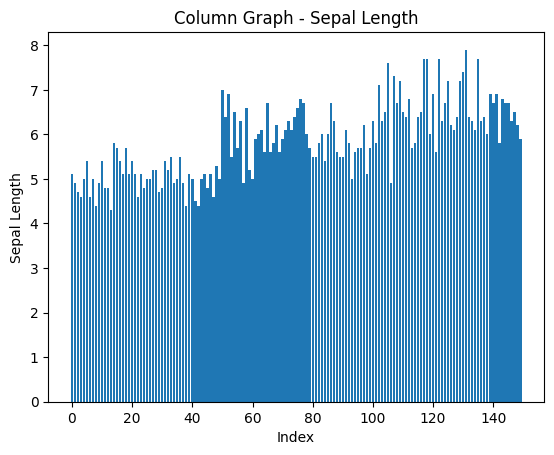

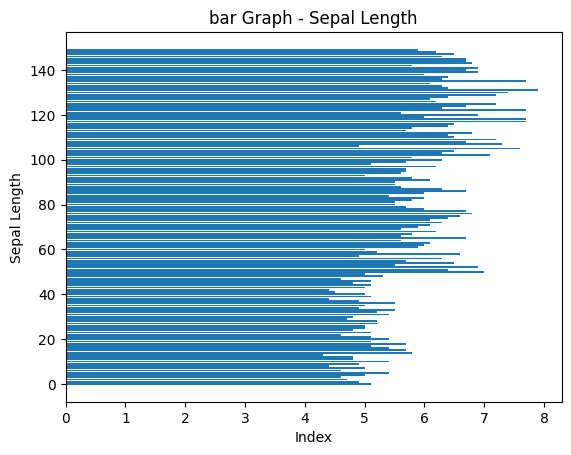

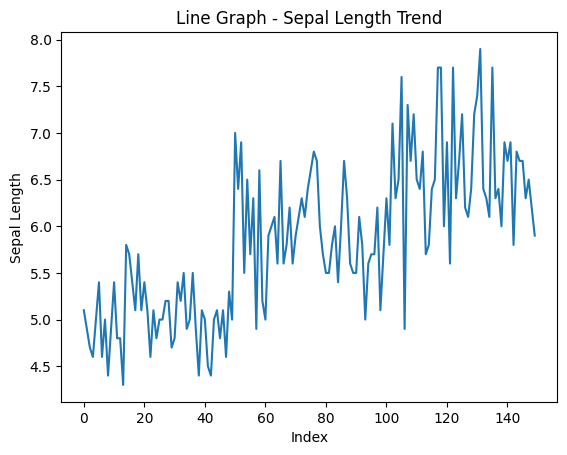

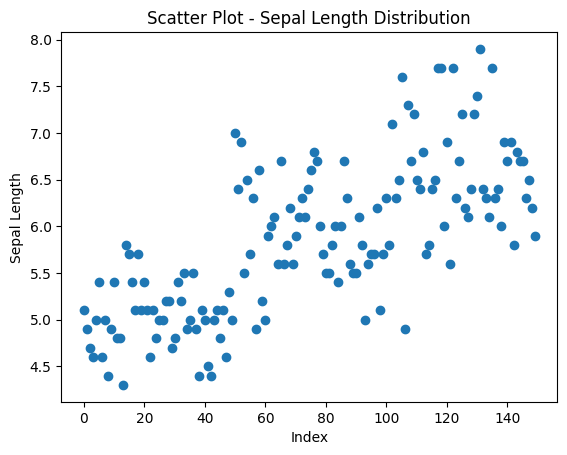

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# load data
data = load_iris()
sepal_length = data.data[:, 0]

# -------- Column Graph --------
plt.figure()
plt.bar(range(len(sepal_length)), sepal_length)
plt.title("Column Graph - Sepal Length")
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.show()

plt.figure()
plt.barh(range(len(sepal_length)), sepal_length)
plt.title("bar Graph - Sepal Length")
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.show()
# -------- Line Graph --------
plt.figure()
plt.plot(sepal_length)
plt.title("Line Graph - Sepal Length Trend")
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.show()

# -------- Scatter Plot --------
plt.figure()
plt.scatter(range(len(sepal_length)), sepal_length)
plt.title("Scatter Plot - Sepal Length Distribution")
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.show()

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


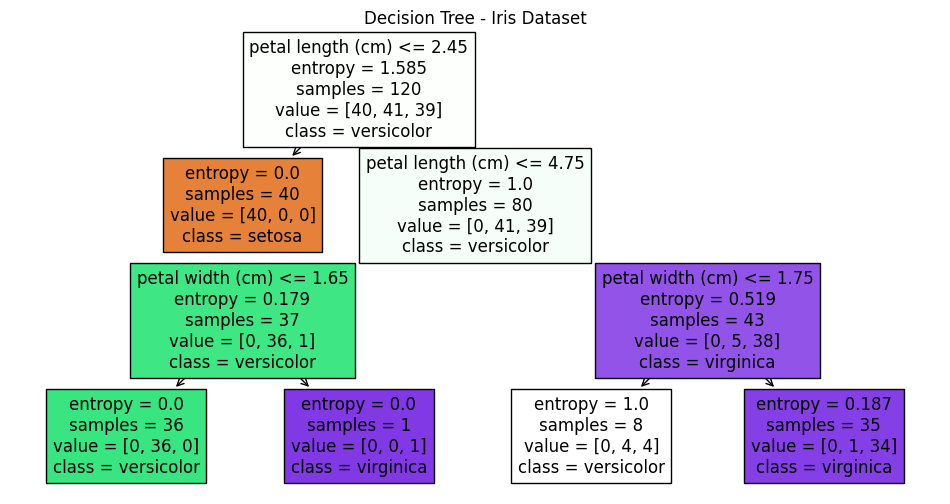

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# load dataset
data = load_iris()
X = data.data
y = data.target

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
model = DecisionTreeClassifier(criterion='entropy', max_depth=3)
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# visualize tree
plt.figure(figsize=(12,6))
plot_tree(model,
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True)

plt.title("Decision Tree - Iris Dataset")
plt.show()

In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier   # ✅ changed
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# load dataset
data = load_iris()
X = data.data
y = data.target

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
model = RandomForestClassifier(n_estimators=100, random_state=42)   # ✅ changed
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Data:
    Year  Life_Expectancy
0  1970             70.6
1  1970             72.2
2  1970             71.9
3  1970             72.0
4  1970             70.9

Shape: (274, 2)

--- Descriptive Analysis ---
              Year  Life_Expectancy
count   274.000000       274.000000
mean   1996.992701        77.909489
std      14.180933         3.276263
min    1970.000000        70.600000
25%    1985.250000        75.525000
50%    1998.000000        78.100000
75%    2009.000000        80.575000
max    2020.000000        84.700000

Mean Life Expectancy: 77.90948905109488
Max Life Expectancy: 84.7
Min Life Expectancy: 70.6


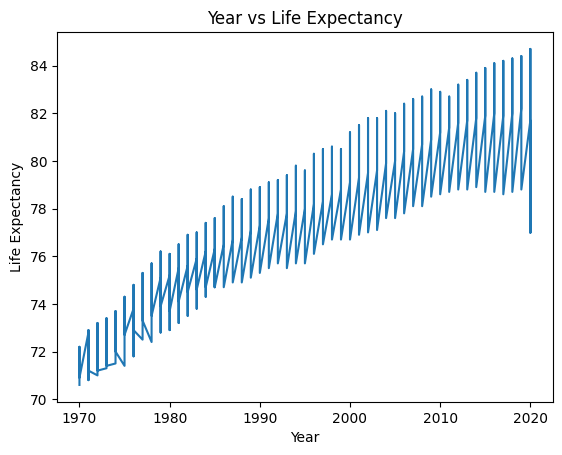

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = sns.load_dataset('healthexp')

# select useful columns
df = df[['Year', 'Life_Expectancy']]

# display data
print("Data:\n", df.head())

print("\nShape:", df.shape)

print("\n--- Descriptive Analysis ---")
desc = df.describe()
print(desc)

# key stats
print("\nMean Life Expectancy:", desc.loc["mean", "Life_Expectancy"])
print("Max Life Expectancy:", desc.loc["max", "Life_Expectancy"])
print("Min Life Expectancy:", desc.loc["min", "Life_Expectancy"])

# one simple plot
plt.plot(df['Year'], df['Life_Expectancy'])
plt.title("Year vs Life Expectancy")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.show()

Data:
    MedInc  Target
0  8.3252   4.526
1  8.3014   3.585
2  7.2574   3.521
3  5.6431   3.413
4  3.8462   3.422

Shape: (20640, 2)

Description:
              MedInc        Target
count  20640.000000  20640.000000
mean       3.870671      2.068558
std        1.899822      1.153956
min        0.499900      0.149990
25%        2.563400      1.196000
50%        3.534800      1.797000
75%        4.743250      2.647250
max       15.000100      5.000010

Predictions: [0 0 0 1 0]


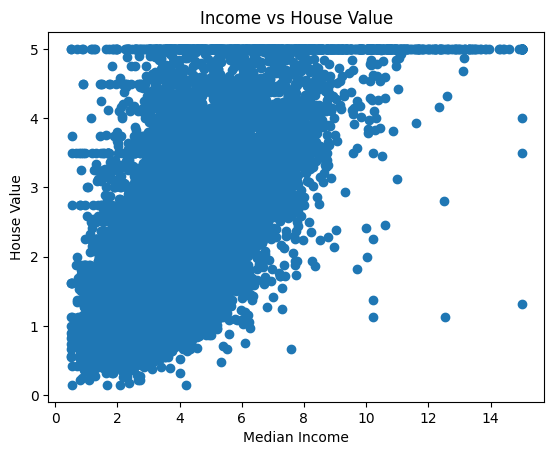

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# -------- Load Dataset --------
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

# take only 1 feature (2D total with target)
df = df[['MedInc']]
df['Target'] = data.target

# -------- Display --------
print("Data:\n", df.head())
print("\nShape:", df.shape)
print("\nDescription:\n", df.describe())

# -------- Binary Target --------
df['High_Value'] = (df['Target'] > df['Target'].mean()).astype(int)

X = df[['MedInc']]
y = df['High_Value']

# -------- Train --------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LogisticRegression()
model.fit(X_train, y_train)

# -------- Prediction --------
y_pred = model.predict(X_test)
print("\nPredictions:", y_pred[:5])

# -------- Plot --------
plt.scatter(df['MedInc'], df['Target'])
plt.title("Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.show()

Weather Data:
    Temperature  Rain
0           30     0
1           32     0
2           35     1
3           28     1
4           25     1

Shape: (20, 2)

Description:
        Temperature       Rain
count     20.00000  20.000000
mean      28.50000   0.600000
std        5.91608   0.502625
min       19.00000   0.000000
25%       23.75000   0.000000
50%       28.50000   1.000000
75%       33.25000   1.000000
max       38.00000   1.000000

Predictions: [1 1 1 0]


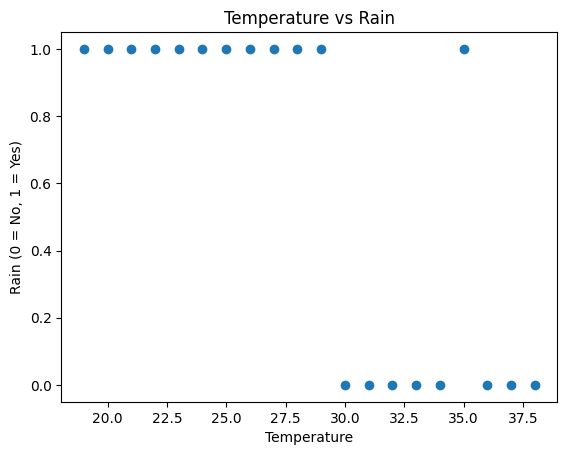

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# -------- Dataset (2D: Temperature → Rain) --------
data = {
    "Temperature": [30,32,35,28,25,27,33,31,29,26,34,36,24,23,22,37,38,21,20,19],
    "Rain":        [0,0,1,1,1,1,0,0,1,1,0,0,1,1,1,0,0,1,1,1]
}

df = pd.DataFrame(data)

# -------- Display --------
print("Weather Data:\n", df.head())
print("\nShape:", df.shape)
print("\nDescription:\n", df.describe())

# -------- Features --------
X = df[["Temperature"]]
y = df["Rain"]

# -------- Train --------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LogisticRegression()
model.fit(X_train, y_train)

# -------- Prediction --------
y_pred = model.predict(X_test)
print("\nPredictions:", y_pred)

# -------- Plot (2D) --------
plt.scatter(df["Temperature"], df["Rain"])
plt.title("Temperature vs Rain")
plt.xlabel("Temperature")
plt.ylabel("Rain (0 = No, 1 = Yes)")
plt.show()